# Model Training Pipeline
## Week 2, Day 3 — Scikit-Learn Model Training & Cross-Validation

This notebook trains two supervised ML models on the feature-engineered dataset from Day 2.
The goal is to classify user score ranges (Low/Mid/High) using engineered features like age group, day of week, and holiday status.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import joblib

# Load dataset
df = pd.read_csv('features_v1.csv')
print("Shape:", df.shape)
print(df.head())


Shape: (97564, 11)
   User_ID        Age      Score  day_of_week  month  is_weekend  is_holiday  \
0        1  34.967142  65.458919            6      1           1           1   
1        2  28.617357  32.669678            0      1           0           1   
2        3  36.476885  58.631558            1      1           0           0   
3        4  45.230299  40.711423            2      1           0           0   
4        5  27.658466  45.088958            3      1           0           0   

   age_Young  age_Mid  age_Senior  age_Elder  
0          0        1           0          0  
1          0        1           0          0  
2          0        0           1          0  
3          0        0           1          0  
4          0        1           0          0  


## Step 1: Create Target Variable
We bin the Score column into 3 classes:
- **Class 0** — Low score (0–40)
- **Class 1** — Mid score (40–70)
- **Class 2** — High score (70–100)

This converts our regression problem into a classification task.

In [2]:
df['target'] = pd.cut(df['Score'], bins=[0, 40, 70, 100],
                      labels=[0, 1, 2]).astype(int)

print("Target distribution:")
print(df['target'].value_counts())

X = df.drop(columns=['User_ID', 'Score', 'target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

Target distribution:
target
1    66419
0    23130
2     8015
Name: count, dtype: int64

Train size: (78051, 9)
Test size: (19513, 9)


## Step 2: Cross-Validation
We use **StratifiedKFold** with 5 folds instead of regular KFold.
StratifiedKFold ensures each fold has the same class distribution as the full dataset.
This is critical when classes are imbalanced, Class 1 dominates with 66k rows vs Class 2 with only 8k.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')
print("Random Forest CV Accuracy:")
print(f"  Mean: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='accuracy')
print("\nLogistic Regression CV Accuracy:")
print(f"  Mean: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")

Random Forest CV Accuracy:
  Mean: 0.5379 ± 0.0019

Logistic Regression CV Accuracy:
  Mean: 0.6808 ± 0.0000


## Step 3: Train Final Models & Classification Report
Training both models on the full training set and evaluating on the test set.
The classification report shows precision, recall, and F1 score for each class.
F1 score matters more than accuracy here because our dataset is imbalanced, Class 1 has 66k rows, Class 2 has only 8k.

In [4]:
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)

print("=" * 50)
print("Random Forest Classification Report:")
print("=" * 50)
print(classification_report(y_test, rf_pred))

print("=" * 50)
print("Logistic Regression Classification Report:")
print("=" * 50)
print(classification_report(y_test, lr_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.22      0.23      4626
           1       0.68      0.71      0.69     13284
           2       0.08      0.08      0.08      1603

    accuracy                           0.54     19513
   macro avg       0.34      0.34      0.34     19513
weighted avg       0.53      0.54      0.53     19513

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4626
           1       0.68      1.00      0.81     13284
           2       0.00      0.00      0.00      1603

    accuracy                           0.68     19513
   macro avg       0.23      0.33      0.27     19513
weighted avg       0.46      0.68      0.55     19513



D:\Prosensia Internship\ML Tasks\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Prosensia Internship\ML Tasks\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Prosensia Internship\ML Tasks\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='f1_weighted')
lr_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='f1_weighted')

print("Random Forest CV F1 (weighted):")
print(f"  Mean: {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

print("\nLogistic Regression CV F1 (weighted):")
print(f"  Mean: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)

print("\n" + "=" * 50)
print("Random Forest Classification Report:")
print("=" * 50)
print(classification_report(y_test, rf_pred, zero_division=0))

print("=" * 50)
print("Logistic Regression Classification Report:")
print("=" * 50)
print(classification_report(y_test, lr_pred, zero_division=0))

Random Forest CV F1 (weighted):
  Mean: 0.4795 ± 0.0037

Logistic Regression CV F1 (weighted):
  Mean: 0.3345 ± 0.0294

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.32      0.27      4626
           1       0.68      0.53      0.59     13284
           2       0.08      0.15      0.11      1603

    accuracy                           0.45     19513
   macro avg       0.33      0.33      0.32     19513
weighted avg       0.53      0.45      0.48     19513

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.24      0.33      0.28      4626
           1       0.68      0.27      0.38     13284
           2       0.08      0.42      0.14      1603

    accuracy                           0.29     19513
   macro avg       0.34      0.34      0.27     19513
weighted avg       0.53      0.29      0.34     19513



## Step 4: Confusion Matrix
Visual representation of model predictions vs actual labels.
Rows = actual class, Columns = predicted class.
Diagonal values are correct predictions, higher diagonal numbers mean better performance.

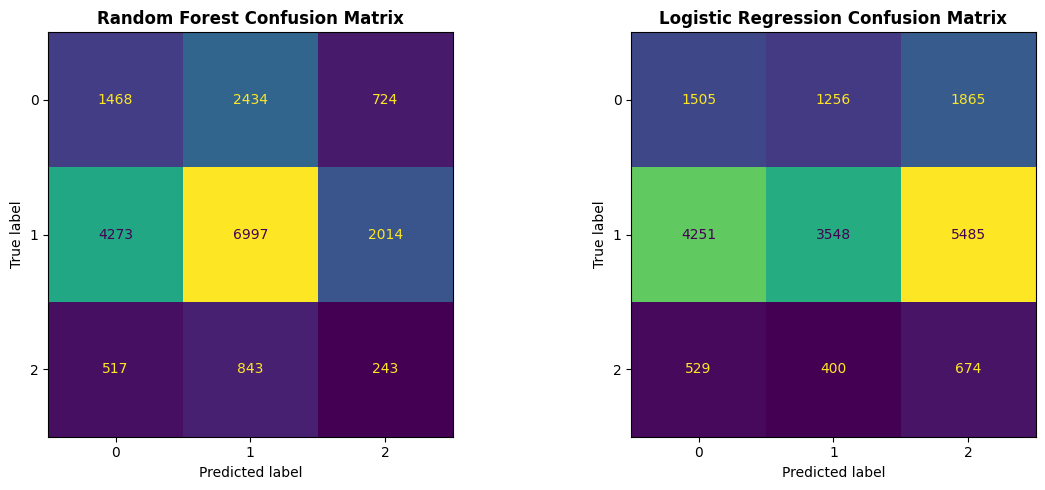

Saved confusion_matrices.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, ax=axes[0], colorbar=False
)
axes[0].set_title('Random Forest Confusion Matrix', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, ax=axes[1], colorbar=False
)
axes[1].set_title('Logistic Regression Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrices.png")

## Step 5: Save Models
Both models are saved as .pkl files using joblib.
This allows us to reload and use the trained models later without retraining from scratch.

In [7]:
# Save models
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(lr, 'logistic_regression_model.pkl')
print("Models saved successfully.")
print("random_forest_model.pkl")
print("logistic_regression_model.pkl")

Models saved successfully.
random_forest_model.pkl
logistic_regression_model.pkl
